In [1]:
import pandas as pd

In [2]:
with open("household_power_consumption.txt", "r") as f:
    for _ in range(5):
        print(f.readline())

Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3

16/12/2006;17:24:00;4.216;0.418;234.840;18.400;0.000;1.000;17.000

16/12/2006;17:25:00;5.360;0.436;233.630;23.000;0.000;1.000;16.000

16/12/2006;17:26:00;5.374;0.498;233.290;23.000;0.000;2.000;17.000

16/12/2006;17:27:00;5.388;0.502;233.740;23.000;0.000;1.000;17.000



In [3]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values=["?"]
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df.shape

(2075259, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [6]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df[["Date", "Time", "Datetime"]].head()

,Date,Time,Datetime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [7]:
df["Datetime"].isna().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

In [9]:
df["Datetime"].min(), df["Datetime"].max()

(Timestamp('2006-12-16 17:24:00'), Timestamp('2010-11-26 21:02:00'))

In [10]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2075259
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-06 07:12:59.999994112
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-12 00:18:30
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-12-06 07:13:00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-12-01 14:07:30
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN


In [11]:
measurement_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df[measurement_cols].isna().all(axis=1).sum()

np.int64(25979)

In [12]:
df[df[measurement_cols].isna().all(axis=1)].head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:23:00
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:24:00
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:08:00
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:09:00
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-01-14 18:36:00


In [13]:
missing_pct = df[measurement_cols].isnull().mean() * 100
missing_pct

Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64

In [14]:
df["complete_case"] = df[measurement_cols].notna().all(axis=1)
df["complete_case"].value_counts(dropna=False)

complete_case
True     2049280
False      25979
Name: count, dtype: int64

In [15]:
df_clean = df[df["complete_case"]].copy()
df_clean.shape

(2049280, 11)

In [16]:
df_clean[measurement_cols].describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [17]:
df_clean["hour"] = df_clean["Datetime"].dt.hour
df_clean["day_name"] = df_clean["Datetime"].dt.day_name()
df_clean["month"] = df_clean["Datetime"].dt.month
df_clean["year"] = df_clean["Datetime"].dt.year
df_clean["date_only"] = df_clean["Datetime"].dt.date

In [18]:
hourly_power = df_clean.groupby("hour")["Global_active_power"].mean()
hourly_power

hour
0     0.659434
1     0.539325
2     0.480621
3     0.444866
4     0.443847
5     0.453674
6     0.791600
7     1.502246
8     1.461016
9     1.331645
10    1.260627
11    1.245822
12    1.207075
13    1.144532
14    1.082839
15    0.990760
16    0.948905
17    1.055109
18    1.326451
19    1.733335
20    1.899064
21    1.877697
22    1.412615
23    0.902142
Name: Global_active_power, dtype: float64

In [19]:
weekday_power = df_clean.groupby("day_name")["Global_active_power"].mean()
weekday_power

day_name
Friday       1.043394
Monday       0.999546
Saturday     1.248335
Sunday       1.220188
Thursday     0.981809
Tuesday      1.069796
Wednesday    1.082588
Name: Global_active_power, dtype: float64

In [20]:
yearly_power = df_clean.groupby("year")["Global_active_power"].mean()
yearly_power

year
2006    1.901295
2007    1.117008
2008    1.072097
2009    1.078637
2010    1.061000
Name: Global_active_power, dtype: float64

In [21]:
daily_power = df_clean.groupby("date_only")["Global_active_power"].mean().sort_values(ascending=False)
daily_power.head(10)

date_only
2006-12-23    3.314851
2006-12-16    3.053475
2007-02-03    2.798418
2006-12-26    2.732021
2007-02-18    2.659557
2007-02-04    2.497181
2007-02-11    2.480019
2007-03-31    2.437160
2006-12-31    2.426525
2007-03-11    2.417108
Name: Global_active_power, dtype: float64

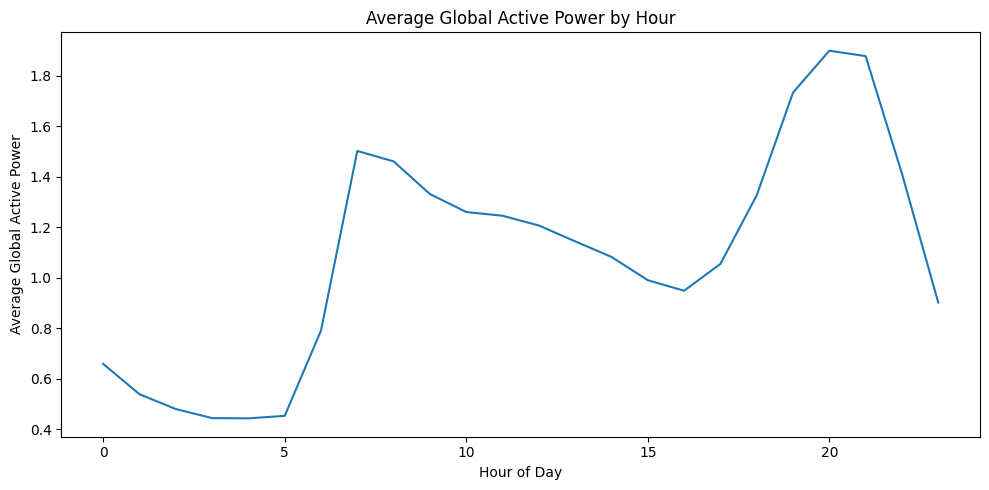

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(hourly_power.index, hourly_power.values)
plt.title("Average Global Active Power by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.tight_layout()
plt.show()

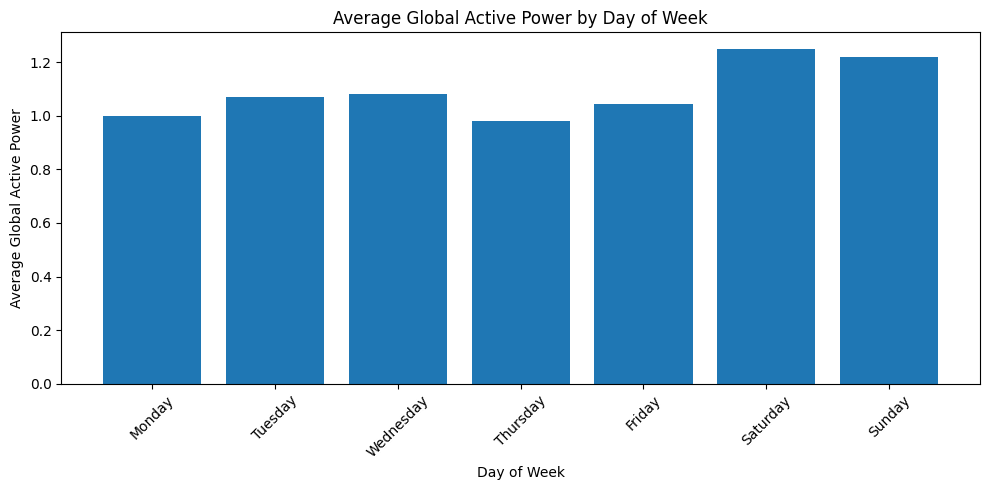

In [23]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_power = weekday_power.reindex(weekday_order)

plt.figure(figsize=(10, 5))
plt.bar(weekday_power.index, weekday_power.values)
plt.title("Average Global Active Power by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Findings

The dataset was successfully prepared for time-series analysis by combining the original date and time columns into a single datetime field and excluding rows with incomplete measurement data.

Only 1.25% of records contained missing values across all measurement columns, so a clean subset of complete observations was created for further analysis.

The analysis shows a clear daily consumption pattern: energy use is lowest overnight and rises sharply in the morning, with the strongest peak in the evening around 20:00–21:00.

Weekly patterns also show that average household power consumption is higher on weekends than on weekdays, suggesting different usage behavior when residents spend more time at home.

Year-level averages should be interpreted carefully because the dataset begins in December 2006 and ends in November 2010, meaning the first and last years are incomplete.

In [25]:
df_clean.to_csv("household_power_clean.csv", index=False)